In [1]:
import pandas as pd 
import numpy as np 

In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\Transaction_Data_250k.csv")
df = data.copy()
df.head()

,Transaction_ID,Customer_ID,Card_ID,Merchant_ID,Transaction_Date,Transaction_Time,Transaction_Amount,Payment_Method,Transaction_Channel,Device_Type,Transaction_Status,Is_International,Fraud_Flag,Fraud_Reason,Merchant_Risk_Level,Merchant_Category,Customer_State,Customer_City,Merchant_State,Merchant_City
0,TXN1000001,CUST100660,CARD500875,MER100380,2024-03-03,05:50:10,21748.02,Debit Card,Mobile App,Android Mobile,Successful,1,0,NaN,Low,Hotel,Tamil Nadu,Madurai,Tamil Nadu,Salem
1,TXN1000002,CUST111388,CARD514772,MER100017,2023-11-08,06:55:15,9960.60,Debit Card,POS,POS Terminal,Successful,0,0,NaN,Low,Travel,Kerala,Kollam,Haryana,Nuh
2,TXN1000003,CUST115872,CARD520625,MER100143,2023-01-11,02:17:28,838.61,Debit Card,ATM,ATM Machine,Successful,0,0,NaN,Low,Food Delivery,Uttar Pradesh,Agra,West Bengal,Kolkata
3,TXN1000004,CUST109049,CARD511773,MER100053,2023-05-25,01:48:56,52694.99,Credit Card,POS,POS Terminal,Successful,0,0,NaN,Low,Financial Services,Punjab,Ludhiana,Madhya Pradesh,Indore
4,TXN1000005,CUST114459,CARD518771,MER100064,2023-10-22,00:23:32,1043.40,Debit Card,Online Web,Android Mobile,Successful,0,0,NaN,Low,Entertainment,Maharashtra,Thane,Madhya Pradesh,Jabalpur


In [3]:
df.shape

(250000, 20)

In [4]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Card_ID', 'Merchant_ID',
       'Transaction_Date', 'Transaction_Time', 'Transaction_Amount',
       'Payment_Method', 'Transaction_Channel', 'Device_Type',
       'Transaction_Status', 'Is_International', 'Fraud_Flag', 'Fraud_Reason',
       'Merchant_Risk_Level', 'Merchant_Category', 'Customer_State',
       'Customer_City', 'Merchant_State', 'Merchant_City'],
      dtype='object')

In [5]:
X = df[['Transaction_Amount','Payment_Method', 'Transaction_Channel', 'Device_Type','Transaction_Status', 'Is_International']]


In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_cols = ['Transaction_Amount', 'Is_International']
cat_cols = ['Payment_Method', 'Transaction_Channel', 'Device_Type', 'Transaction_Status']

# Numeric pipeline
num_transformations = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_transformations = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformations, num_cols),
    ('cat', cat_transformations, cat_cols)
])

X_preprocessed = preprocessor.fit_transform(X)


In [7]:
# for knowing how many clusters will have
from sklearn.cluster import KMeans

wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i , init='k-means++' , random_state=42)
    kmeans.fit(X_preprocessed)

    wcss.append(kmeans.inertia_)


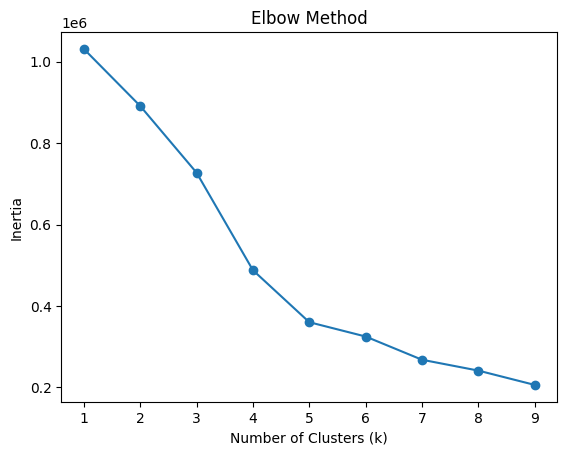

In [8]:
import matplotlib.pyplot as plt

plt.plot(range(1,10), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [9]:
from sklearn.metrics import silhouette_score
import numpy as np

sample_idx = np.random.choice(X_preprocessed.shape[0], 10000, replace=False)
X_sample = X_preprocessed[sample_idx]

for k in [3,4,5]:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_sample)
    print(k, silhouette_score(X_sample, labels))


3 0.36148227998163657
4 0.3853232143896953
5 0.4638319954279482


In [10]:
model = KMeans(n_clusters=5, random_state=42)
labels = model.fit_predict(X_preprocessed)
X['Cluster'] = labels


C:\Users\bingi\AppData\Local\Temp\ipykernel_15324\3475080288.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cluster'] = labels


In [11]:
# Numeric averages
print(X.groupby('Cluster')[['Transaction_Amount','Is_International']].mean())

# Categorical distributions
print(X.groupby('Cluster')['Payment_Method'].value_counts(normalize=True))
print(X.groupby('Cluster')['Transaction_Channel'].value_counts(normalize=True))


         Transaction_Amount  Is_International
Cluster                                      
0              13837.401364          0.000000
1              13753.455636          0.000000
2             868870.768903          0.324451
3              25871.192331          1.000000
4              13979.264260          0.000000
Cluster  Payment_Method
0        Credit Card       0.500294
         Debit Card        0.499706
1        Credit Card       0.314307
         Debit Card        0.309381
         UPI               0.308347
         Net Banking       0.067965
2        Debit Card        0.510972
         Credit Card       0.346395
         UPI               0.119122
         Net Banking       0.023511
3        Debit Card        0.510392
         Credit Card       0.352042
         UPI               0.110797
         Net Banking       0.026769
4        Debit Card        1.000000
Name: proportion, dtype: float64
Cluster  Transaction_Channel
0        POS                    1.000000
1        Mo

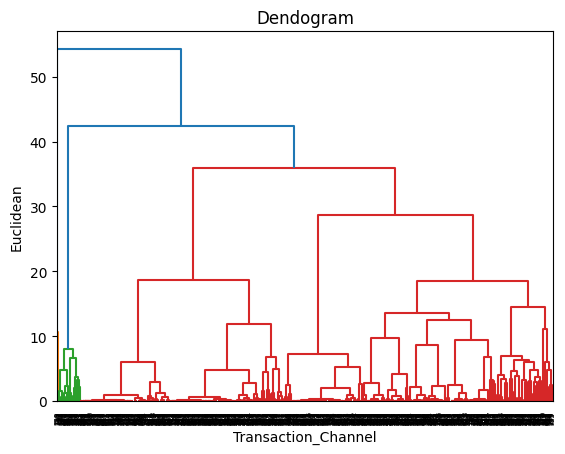

In [16]:
import scipy.cluster.hierarchy as sch 
import numpy as np
sample_idx = np.random.choice(X_preprocessed.shape[0], 1000, replace=False)
X_sample = X_preprocessed[sample_idx]
dendrogram = sch.dendrogram(sch.linkage(X_sample, method='ward'))

plt.title('Dendogram')
plt.xlabel('Transaction_Channel')
plt.ylabel('Euclidean')
plt.show()